In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("lakshmi25npathi/imdb-dataset-of-50k-movie-reviews")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'imdb-dataset-of-50k-movie-reviews' dataset.
Path to dataset files: /kaggle/input/imdb-dataset-of-50k-movie-reviews


In [ ]:
import pandas as pd
import numpy as np
import os
print(f"Files in the dataset directory: {os.listdir(path)}")
csv_file_name = 'IMDB Dataset.csv'
full_csv_path = os.path.join(path, csv_file_name)

df = pd.read_csv(full_csv_path)
print("\nInitial Data Head")
print(df.head())
print("\nDataFrame Info")
df.info()
print("\nMissing Values & Duplicates")
print(f"Total Missing Values:\n{df.isnull().sum()}")
print(f"Total Duplicate Rows: {df.duplicated().sum()}")
df.dropna(subset=['review'], inplace=True)
df.drop_duplicates(inplace=True)
print(f"\nDataFrame shape after cleaning (nulls/duplicates removed): {df.shape}")

Files in the dataset directory: ['IMDB Dataset.csv']

Initial Data Head
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive

DataFrame Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB

Missing Values & Duplicates
Total Missing Values:
review       0
sentiment    0
dtype: int64
Total Duplicate Rows: 418

DataFrame shape after cleaning (nulls/duplicates removed): (49582, 2)


In [ ]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    text = re.sub('<.*?>', '', text)
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    words = text.split()
    words = [lemmatizer.lemmatize(word) for word in words]
    return ' '.join(words)
df['clean_review'] = df['review'].apply(preprocess_text)
print("\n--- HTML & Text Preprocessing Complete ---")
print(df[['review', 'clean_review']].head())

[nltk_data] Downloading package wordnet to /root/nltk_data...



--- HTML & Text Preprocessing Complete ---
                                              review  \
0  One of the other reviewers has mentioned that ...   
1  A wonderful little production. <br /><br />The...   
2  I thought this was a wonderful way to spend ti...   
3  Basically there's a family where a little boy ...   
4  Petter Mattei's "Love in the Time of Money" is...   

                                        clean_review  
0  one of the other reviewer ha mentioned that af...  
1  a wonderful little production the filming tech...  
2  i thought this wa a wonderful way to spend tim...  
3  basically there a family where a little boy ja...  
4  petter matteis love in the time of money is a ...  


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
X = df['clean_review']
y = df['sentiment']
tfidf = TfidfVectorizer(max_features=5000)
X_vectorized = tfidf.fit_transform(X)
print(f"Shape of the TF-IDF Feature Matrix: {X_vectorized.shape}")
print(f"Total number of unique features (words) used: {X_vectorized.shape[1]}")
X_train, X_test, y_train, y_test = train_test_split(
    X_vectorized,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print("\nData Split Summary")
print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")

Shape of the TF-IDF Feature Matrix: (49582, 5000)
Total number of unique features (words) used: 5000

--- Data Split Summary ---
Training features shape: (39665, 5000)
Testing features shape: (9917, 5000)


In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
nb_model = MultinomialNB()
lr_model = LogisticRegression(solver='liblinear', random_state=42, max_iter=1000)

print("\nModel Training Status")
nb_model.fit(X_train, y_train)
nb_predictions = nb_model.predict(X_test)
nb_accuracy = accuracy_score(y_test, nb_predictions)
print(f"MNB trained. Test Accuracy: {nb_accuracy:.4f}")
lr_model.fit(X_train, y_train)
lr_predictions = lr_model.predict(X_test)
lr_accuracy = accuracy_score(y_test, lr_predictions)
print(f"LR trained. Test Accuracy: {lr_accuracy:.4f}")


--- Model Training Status ---
MNB trained. Test Accuracy: 0.8496
LR trained. Test Accuracy: 0.8856


     EVALUATION: MULTINOMIAL NAIVE BAYES (MNB)     
              precision    recall  f1-score   support

    negative       0.85      0.85      0.85      4940
    positive       0.85      0.85      0.85      4977

    accuracy                           0.85      9917
   macro avg       0.85      0.85      0.85      9917
weighted avg       0.85      0.85      0.85      9917

     EVALUATION: LOGISTIC REGRESSION (LR)     
              precision    recall  f1-score   support

    negative       0.89      0.88      0.88      4940
    positive       0.88      0.90      0.89      4977

    accuracy                           0.89      9917
   macro avg       0.89      0.89      0.89      9917
weighted avg       0.89      0.89      0.89      9917



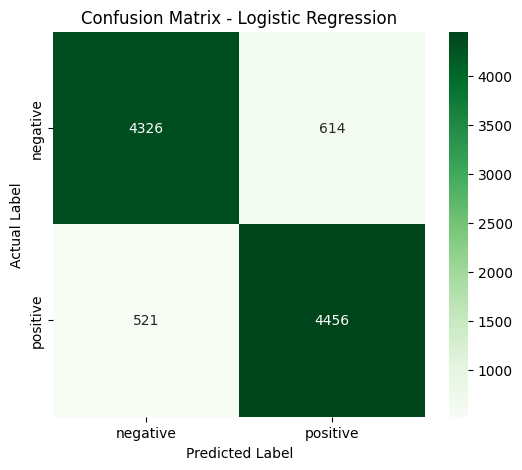

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import numpy as np
le = LabelEncoder()
le.fit(np.array(['positive', 'negative']))
class_names = le.classes_

print("     EVALUATION: MULTINOMIAL NAIVE BAYES (MNB)     ")
print(classification_report(y_test, nb_predictions, target_names=class_names))

print("     EVALUATION: LOGISTIC REGRESSION (LR)     ")
print(classification_report(y_test, lr_predictions, target_names=class_names))

cm_lr = confusion_matrix(y_test, lr_predictions)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Logistic Regression')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

In [ ]:
feature_names = tfidf.get_feature_names_out()
coefficients = lr_model.coef_.flatten()
feature_df = pd.DataFrame({'feature': feature_names, 'coefficient': coefficients})
positive_features = feature_df.sort_values(by='coefficient', ascending=False).head(10)
negative_features = feature_df.sort_values(by='coefficient', ascending=True).head(10)

print("\nTop 10 Words Indicating POSITIVE Sentiment (Highest Coefficients)")
print(positive_features)

print("\nTop 10 Words Indicating NEGATIVE Sentiment (Lowest Coefficients)")
print(negative_features)


Top 10 Words Indicating POSITIVE Sentiment (Highest Coefficients)
        feature  coefficient
1917      great     7.576985
1513  excellent     6.963360
3209    perfect     5.652000
414        best     5.249129
155     amazing     4.972241
4930  wonderful     4.732212
2637      loved     4.530638
1445    enjoyed     4.259320
4510      today     4.256432
1627   favorite     4.221506

Top 10 Words Indicating NEGATIVE Sentiment (Lowest Coefficients)
       feature  coefficient
4949     worst   -10.860444
317      awful    -8.042267
326        bad    -7.957752
4817     waste    -7.762448
489     boring    -7.037637
3308      poor    -6.463560
4417  terrible    -6.047504
3020   nothing    -5.498418
4948     worse    -5.176403
2126  horrible    -5.098264


In [ ]:
rewiew = "It was a good movie"

In [ ]:
nb_model.predict(rewiew)

ValueError: Expected 2D array, got scalar array instead:
array=It was a good movie.
Reshape your data either using array.reshape(-1, 1) if your data has a single feature or array.reshape(1, -1) if it contains a single sample.